In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format='retina'
from tools import _init_paths
from pathlib import Path
import torch
import torchvision.transforms as transforms
import numpy as np
import cv2
import pylab
pylab.rcParams['figure.figsize'] = 10.0, 8.0

import dataset
import models
from config import cfg as conf
from config import update_config
from utils.utils import model_key_helper
from core.inference import get_final_preds_match


class Visualizer:
    SKEL = [[16, 14], [14, 12], [17, 15], [15, 13], [12, 13], [6, 12], [7, 13], 
            [6, 7], [6, 8], [7, 9], [8, 10], [9, 11], [2, 3], [1, 2], [1, 3], 
            [2, 4], [3, 5], [4, 6], [5, 7]]
            
    def plot_results(self, img, pred, vis, scale):
        img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
        plt.figure()
        plt.imshow(img)
        ax = plt.gca()

        vis_head = pred[:5][vis[:5] > 0.5]
        vis_body = pred[5:17][vis[5:17] > 0.5]
        vis_whole = pred[17:][vis[17:] > 0.5]

        GREEN = [(5,6),(6,8),(8,10)]
        YELLOW = [(5,7),(7,9)]
        BLUE = [(5,11),(11,13),(13,15)]
        PINK = [(6,12),(12,14),(14,16)]

        for i, j in self.SKEL:
            ki = min(i, j) - 1
            kj = max(i, j) - 1
            # 0-4 head
            # 5,7,9,11,13,15 left
            # 6,8,10,12,14,16 right

            i, j = i - 1, j - 1
            src = pred[i]
            dst = pred[j]
            if vis[i] <= 0 or vis[j] <= 0:
                continue
            if ki < 5 and kj < 5:
                plt.plot([src[0], dst[0]],[src[1], dst[1]], linewidth=1, color=[250/255, 32/255, 98/255, 1], 
                         solid_capstyle='round', zorder=1)
            if ki >=5 and kj >= 5:
                pair = ki, kj
                trans = 1
                if pair in GREEN:
                    color = (38 / 255, 252 / 255, 145 / 255, trans)
                elif pair in YELLOW:
                    color = [250 / 255, 244 / 255, 60 / 255, trans]
                elif pair in BLUE:
                    color = [104 / 255, 252 / 255, 252 / 255, trans]
                elif pair in PINK:
                    color = [255 / 255, 148 / 255, 212 / 255, trans]
                else:
                    continue
                plt.plot([src[0], dst[0]],[src[1], dst[1]], linewidth=3 * scale, color=color, 
                         solid_capstyle='round', zorder=1)


        for pnt in vis_head:
            circle = plt.Circle((pnt[0], pnt[1]), scale * 1.2, fill=True, color='red', zorder=5)
            ax.add_artist(circle)
        for pnt in vis_body:
            circle = plt.Circle((pnt[0], pnt[1]), scale * 1.2, fill=True, color='red', zorder=5)
            ax.add_artist(circle)
        
        for pnt in vis_whole:
            circle = plt.Circle((pnt[0], pnt[1]), scale * 1.2, fill=True, color='red', zorder=5)
            ax.add_artist(circle)


        plt.axis('off')
        plt.show()

    def plot_part(self, img, pred, vis, part="wholebody"):
        img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
        plt.figure()
        plt.imshow(img)
        ax = plt.gca()

        body = pred[:17][vis[:17]>0]
        foot = pred[17:23][vis[17:23]>0]
        face = pred[23:91][vis[23:91]>0]
        lefthand = pred[91:112][vis[91:112]>0]
        righthand = pred[112:133][vis[112:133]>0]

        if part=='body':
            kpts = body
        elif part=='foot':
            kpts = foot
        elif part=='face':
            kpts = face
        elif part=='lefthand':
            kpts = lefthand
        elif part=='righthand':
            kpts = righthand
        elif part=='wholebody':
            kpts = pred[vis>0]
            
        for pnt in kpts:
            circle = plt.Circle((pnt[0], pnt[1]), 1, fill=True, color='red', zorder=5)
            ax.add_artist(circle)

            
        plt.axis('off')
        plt.show()
        
class Args:
    cfg = '/home/zhhb/Projects/mypose/src/config/wholebody/res50_384x288_adamw_lr1e-4.yaml'
    opts = []
    modelDir = None
    logDir = None
    dataDir = None
    pretrained = '/home/zhhb/Projects/mypose/output/wholebody/pose_transformer/res50_384x288_adamw_lr5e-5_bs64/model_best.pth'

def inference(config, flip_pairs, input, target, target_weight, meta, transform):
    c = meta['center']
    s = meta['scale']
    outputs = model(transform(input)[None, ...])
    preds, maxvals, preds_raw = get_final_preds_match(config, outputs, c, s)
    input_flipped = np.flip(input, 1).copy()
    outputs_flipped = model(transform(input_flipped)[None, ...])
    preds_flipped, maxvals_flipped, preds_raw_flipped = get_final_preds_match(config, outputs_flipped, c, s, flip_pairs)
    preds_raw = (preds_raw + preds_raw_flipped) / 2
    maxvals = (maxvals + maxvals_flipped)/2

    vis = meta['joints_vis'][..., 0]
    return preds_raw[0], vis, np.linalg.norm(meta['scale']) / 2, maxvals.reshape(133)

In [2]:
args = Args()
update_config(conf, args)
model = models.pose_transformer.get_pose_net(conf, is_train=False)
model.load_state_dict(model_key_helper(torch.load(args.pretrained, map_location='cuda')))

normalize = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


valid_dataset = eval('dataset.'+conf.DATASET.DATASET)(
        conf, conf.DATASET.ROOT, conf.DATASET.TEST_SET, False
    )

print(f"Loaded {len(valid_dataset)} images")

/home/zhhb/miniconda3/envs/mypose/lib/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/zhhb/miniconda3/envs/mypose/lib/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


loading annotations into memory...
Done (t=2.41s)
creating index...
index created!
Loaded 6352 images


In [11]:
# VIS_INDICES = [0, 2, 3, 4,6, 8, 9 ,88,121,155]

import random


# VIS_INDICES = [random.randint(0, len(valid_dataset)) for _ in range(10)]
VIS_INDICES = [3682]

In [ ]:
for idx in VIS_INDICES:
    input, target, target_weight, meta = valid_dataset[idx]
    preds_raw, vis, scale = inference(conf, valid_dataset.flip_pairs, input, target, target_weight, meta, transform=normalize)
    Visualizer().plot_results(input, preds_raw, vis, scale)

In [22]:
gt = np.array([[137.14062595367432, 101.77433395385742], [0.0, 0.0], [128.41052055358887, 98.0328598022461], [0.0, 0.0], [105.9616756439209, 104.2686538696289], [130.9048376083374, 150.41350936889648], [72.2883996963501, 142.93056106567383], [175.8025360107422, 182.8396224975586], [57.32250165939331, 200.2998275756836], [213.21728324890137, 172.86235427856445], [114.69178104400635, 201.54700469970703], [87.25430202484131, 235.2202606201172], [53.58102607727051, 240.20890045166016], [187.02695846557617, 235.2202606201172], [119.68041515350342, 230.2316436767578], [133.39915466308594, 297.5781784057617], [52.333871841430664, 306.3082809448242], [177.74751091003418, 296.3063735961914], [176.45121002197266, 289.04711151123047], [121.08756637573242, 301.3030014038086], [75.82672691345215, 312.67664337158203], [67.54311275482178, 314.66471099853516], [41.89882135391235, 310.40975189208984], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [215.82955741882324, 171.27182006835938], [219.88172721862793, 168.0006980895996], [223.9339141845703, 164.72957611083984], [228.63364219665527, 170.45737838745117], [233.7205696105957, 178.88217544555664], [233.42124366760254, 149.41577911376953], [242.6502227783203, 150.03935623168945], [250.38258934020996, 153.03253555297852], [257.4862461090088, 157.5197639465332], [233.2965316772461, 152.78311157226562], [241.7772045135498, 154.4044189453125], [251.00618362426758, 156.6493034362793], [260.23514556884766, 158.6447525024414], [233.79539680480957, 156.27515029907227], [241.5277805328369, 157.02344512939453], [250.25787734985352, 160.14134216308594], [257.4913959503174, 161.51321411132812], [233.92010879516602, 158.52003479003906], [241.27833938598633, 159.64248275756836], [247.26470375061035, 161.51321411132812], [252.87691497802734, 163.134521484375], [115.93894386291504, 202.79415893554688], [122.79830932617188, 202.79415893554688], [129.65768337249756, 202.79415893554688], [135.89347171783447, 207.78277587890625], [137.14062595367432, 209.0299530029297], [137.14062595367432, 206.5356216430664], [140.88210582733154, 211.52426147460938], [140.88210582733154, 214.01856994628906], [142.1292600631714, 217.7600555419922], [137.14062595367432, 207.78277587890625], [139.63494300842285, 212.77141571044922], [140.88210582733154, 217.7600555419922], [142.1292600631714, 220.25436401367188], [135.89347171783447, 210.27710723876953], [139.63494300842285, 215.2657241821289], [140.88210582733154, 217.7600555419922], [140.88210582733154, 221.50151824951172], [133.39915466308594, 212.77141571044922], [135.89347171783447, 215.2657241821289], [137.14062595367432, 219.00720977783203], [139.63494300842285, 221.50151824951172]])

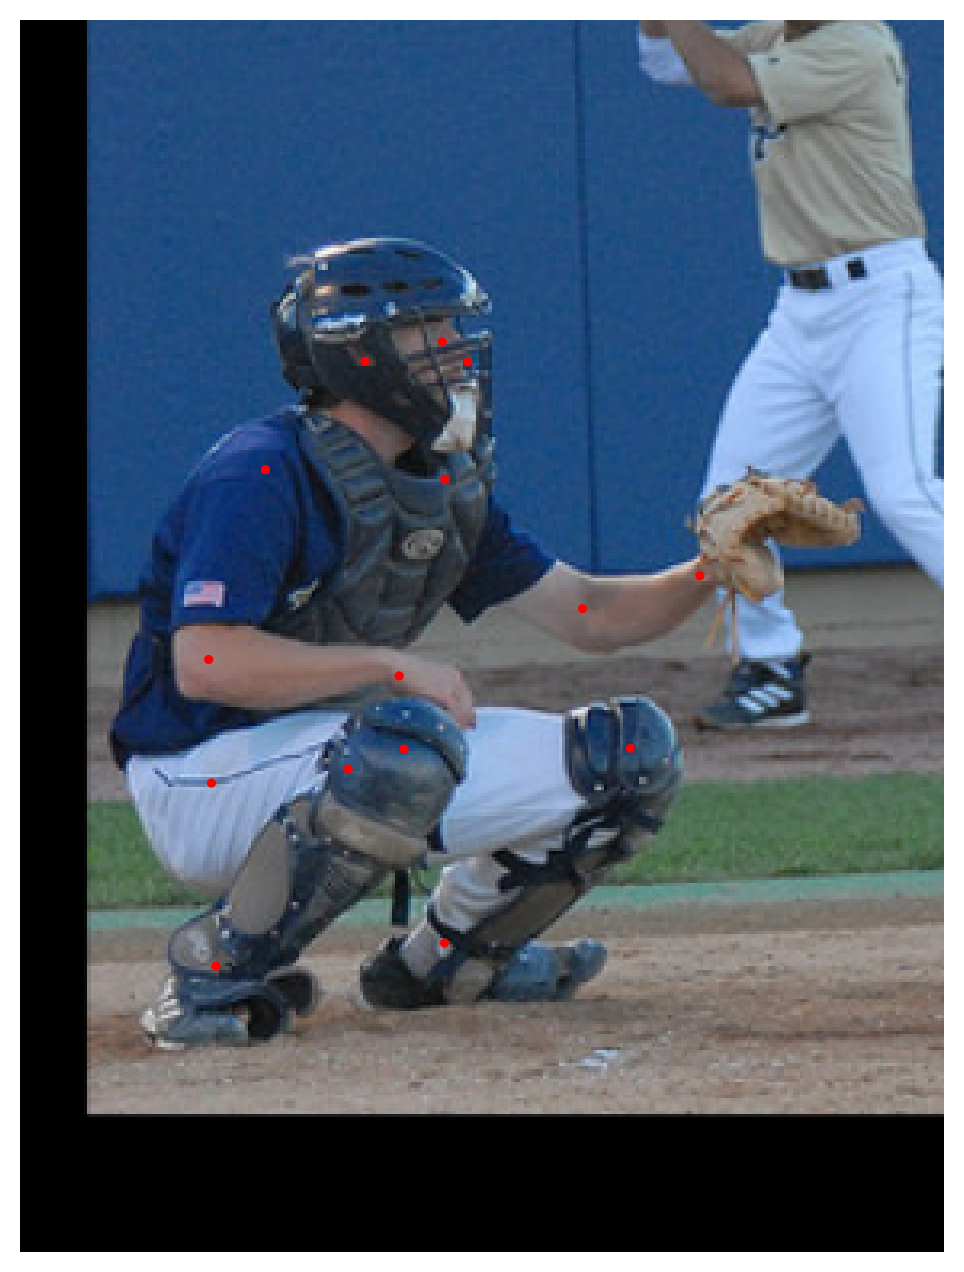

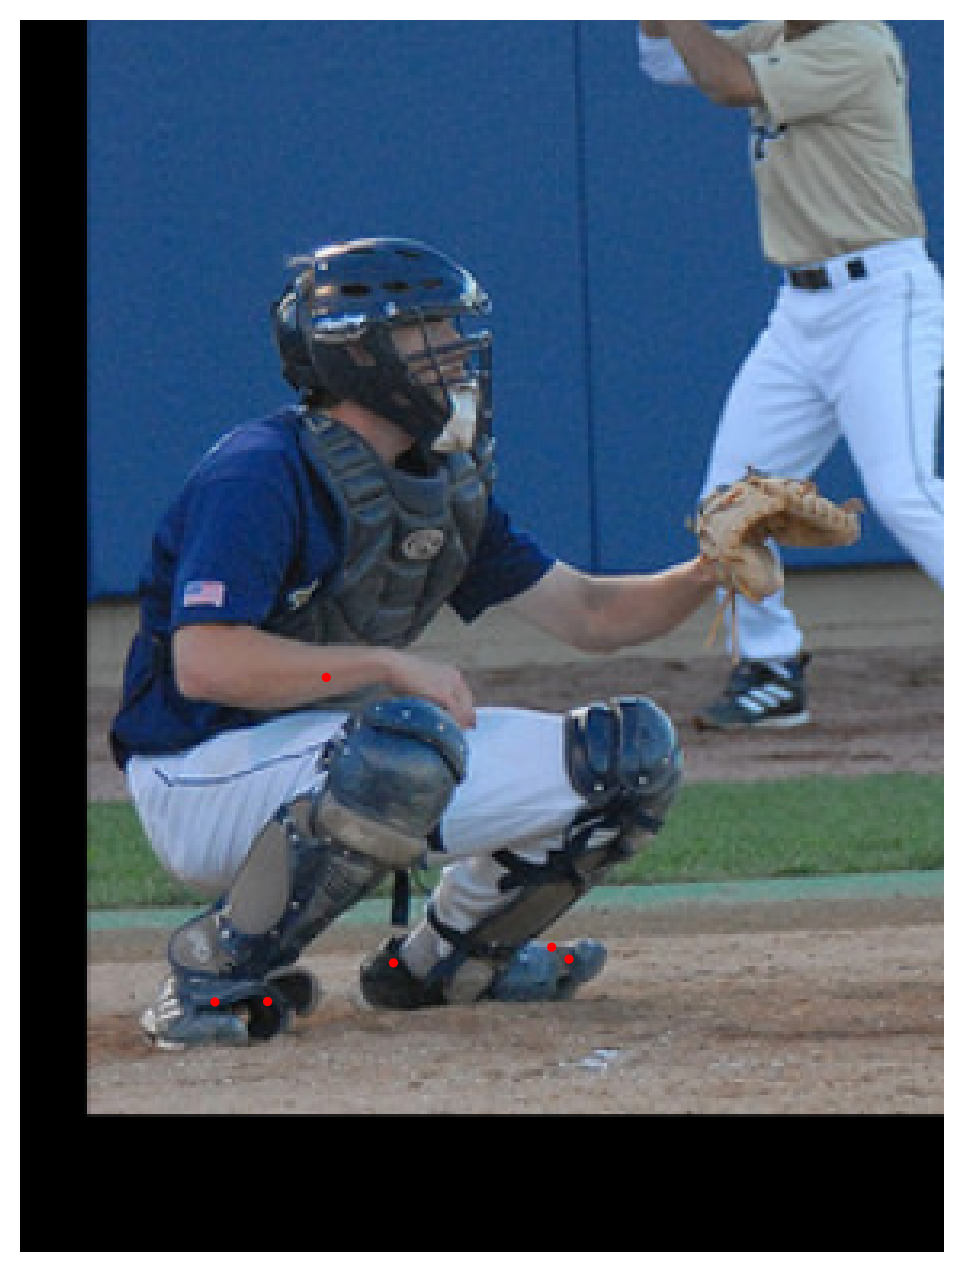

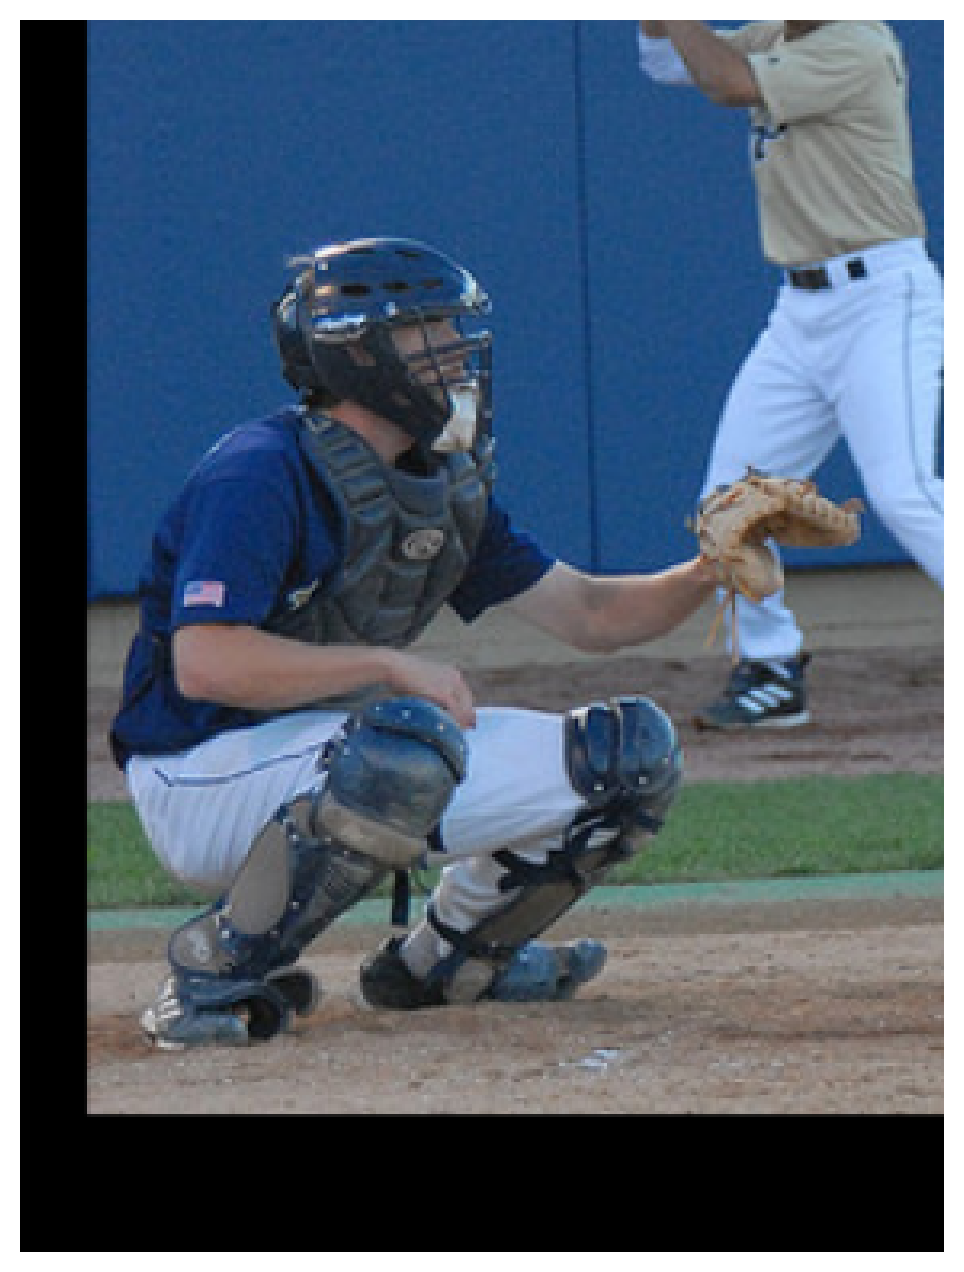

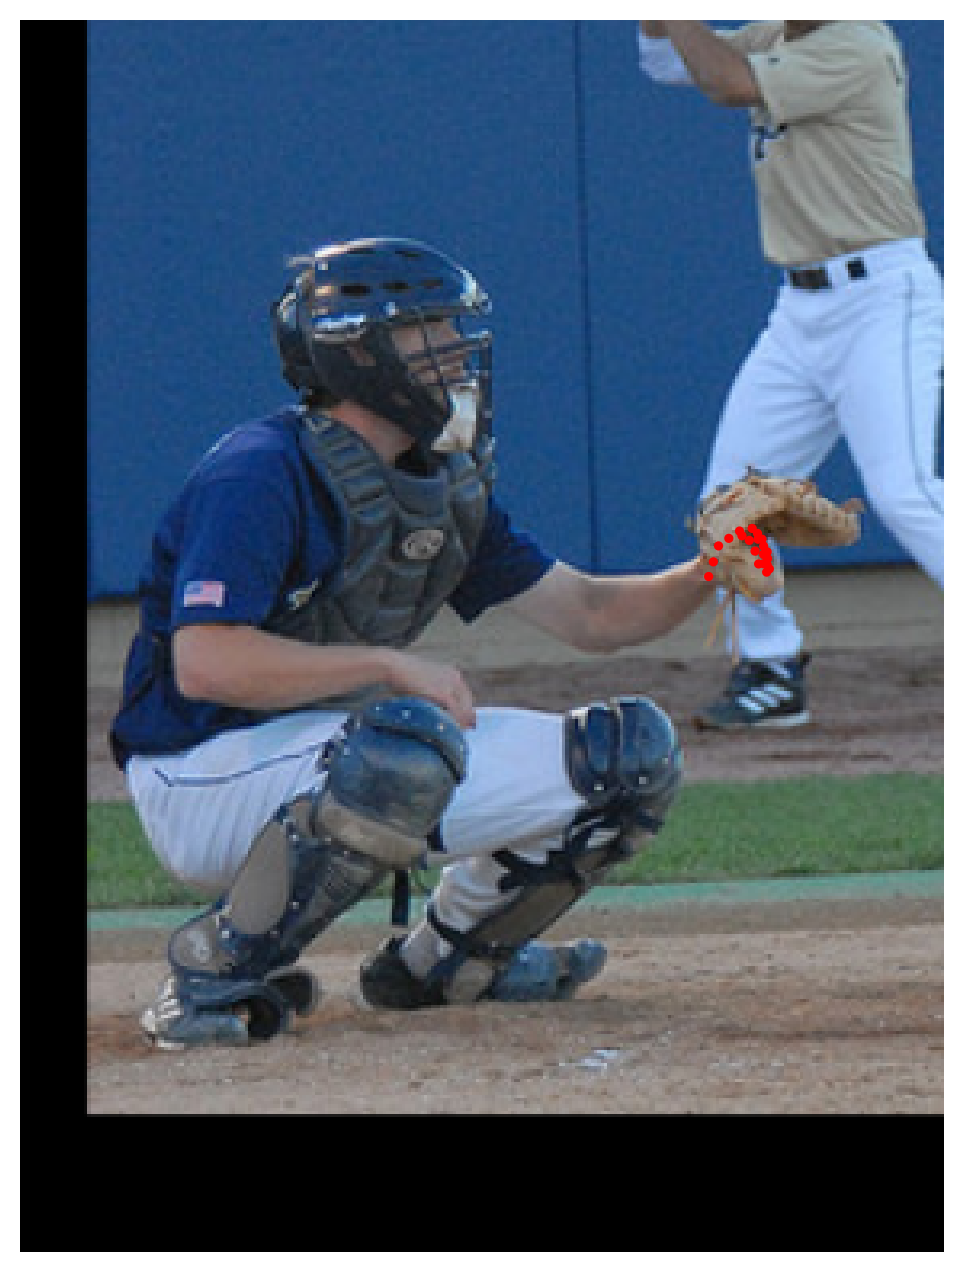

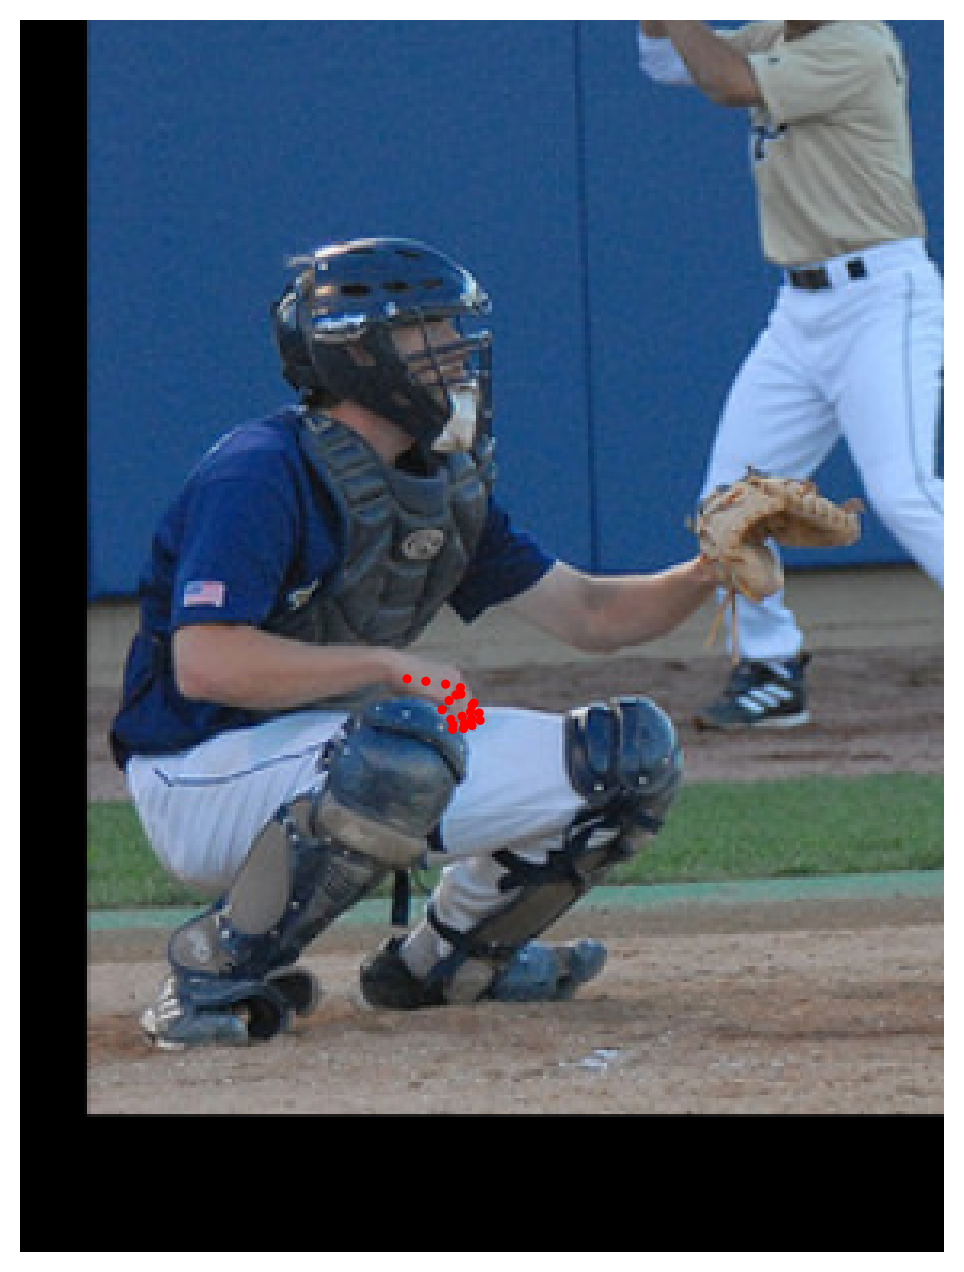

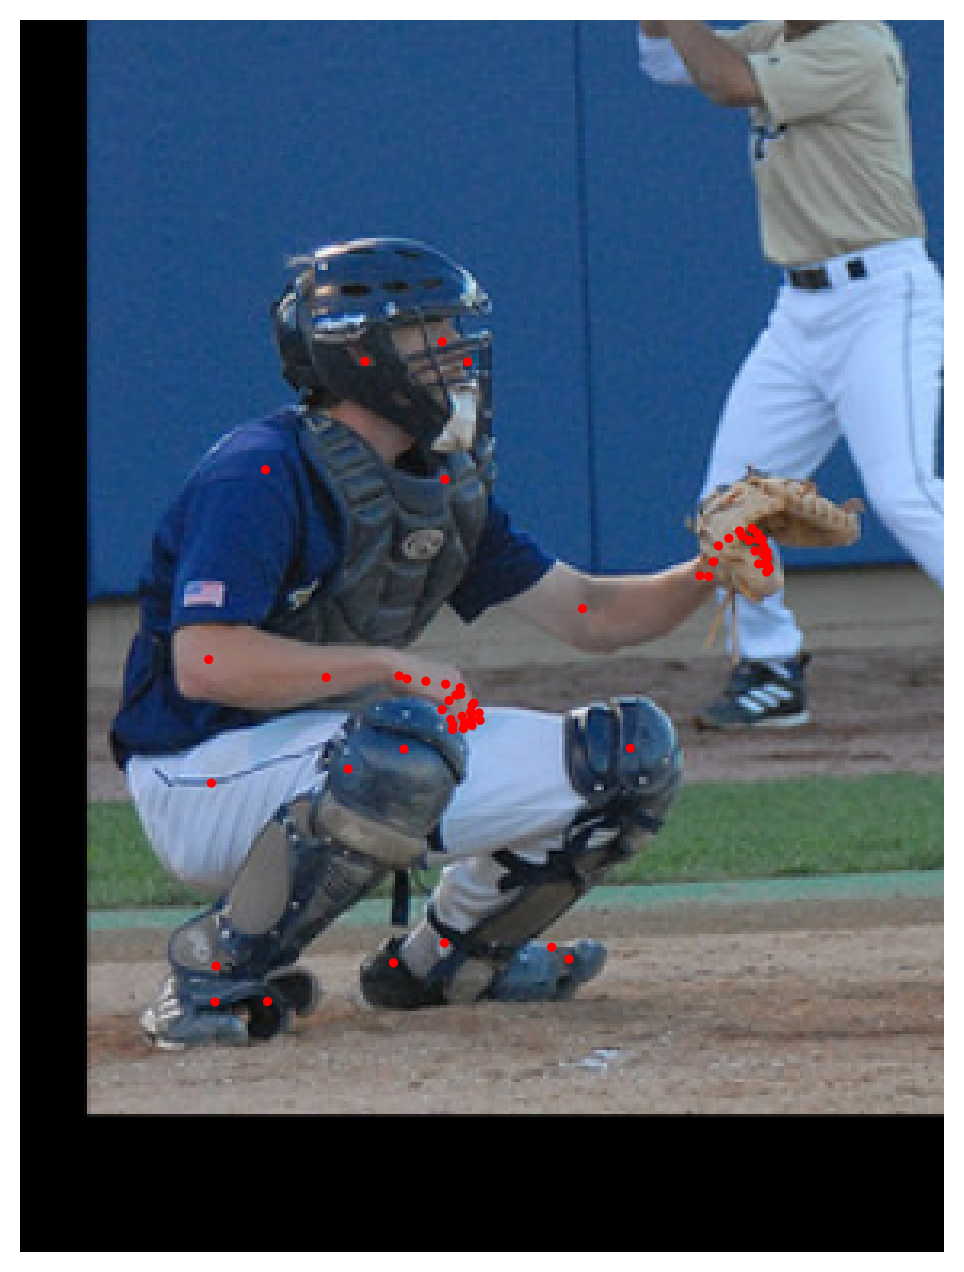

In [24]:
for idx in VIS_INDICES:
    input, target, target_weight, meta = valid_dataset[idx]
    preds_raw, vis, scale , maxvals= inference(conf, valid_dataset.flip_pairs, input, target, target_weight, meta, transform=normalize)
    #preds_raw = gt
    Visualizer().plot_part(input, preds_raw, vis, 'body')
    Visualizer().plot_part(input, preds_raw, vis,'foot')
    Visualizer().plot_part(input, preds_raw, vis, 'face')
    Visualizer().plot_part(input, preds_raw, vis, 'lefthand')
    Visualizer().plot_part(input, preds_raw, vis, 'righthand')
    Visualizer().plot_part(input, preds_raw, vis, 'wholebody')


